<a href="https://colab.research.google.com/github/StudentbcuAKR/Cybersecurity/blob/main/updatedpart2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (123117, 51)


,id.orig_p,id.resp_p,proto,service,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,...,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,flow_duration
0,38667,1883,tcp,mqtt,9,5,3,3,0.281148,0.156193,...,7.714286,11.618477,761.985779,29729182.96,32011597.87,4001449.734,10403073.63,4438.877106,1511693.954,32.011598
1,51143,1883,tcp,mqtt,9,5,3,3,0.282277,0.156821,...,7.714286,11.618477,247.001648,29855277.06,31883584.02,3985448.003,10463455.56,4214.048386,1576435.804,31.883584
2,44761,1883,tcp,mqtt,9,5,3,3,0.280164,0.155647,...,7.428571,11.229866,283.956528,29842149.02,32124053.00,4015506.625,10442377.92,2456.903458,1476048.946,32.124053
3,60893,1883,tcp,mqtt,9,5,3,3,0.281593,0.156440,...,7.428571,11.229866,288.963318,29913774.97,31961063.15,3995132.893,10482528.22,3933.906555,1551892.042,31.961063
4,51087,1883,tcp,mqtt,9,5,3,3,0.282111,0.156728,...,7.714286,11.618477,387.907028,29814704.90,31902361.87,3987795.234,10447019.10,3005.027771,1632083.178,31.902362


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 51 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id.orig_p              123117 non-null  int64  
 1   id.resp_p              123117 non-null  int64  
 2   proto                  123117 non-null  object 
 3   service                123117 non-null  object 
 4   fwd_pkts_tot           123117 non-null  int64  
 5   bwd_pkts_tot           123117 non-null  int64  
 6   fwd_data_pkts_tot      123117 non-null  int64  
 7   bwd_data_pkts_tot      123117 non-null  int64  
 8   fwd_pkts_per_sec       123117 non-null  float64
 9   bwd_pkts_per_sec       123117 non-null  float64
 10  flow_pkts_per_sec      123117 non-null  float64
 11  down_up_ratio          123117 non-null  float64
 12  fwd_header_size_tot    123117 non-null  int64  
 13  fwd_header_size_min    123117 non-null  int64  
 14  fwd_header_size_max    123117 non-nu

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.304676,3.642935,0.997310
1,Ridge Regression,0.309511,3.650713,0.997299
2,Random Forest Regressor,0.296192,18.339137,0.931830
3,Gradient Boosting Regressor,0.174977,6.333311,0.991870


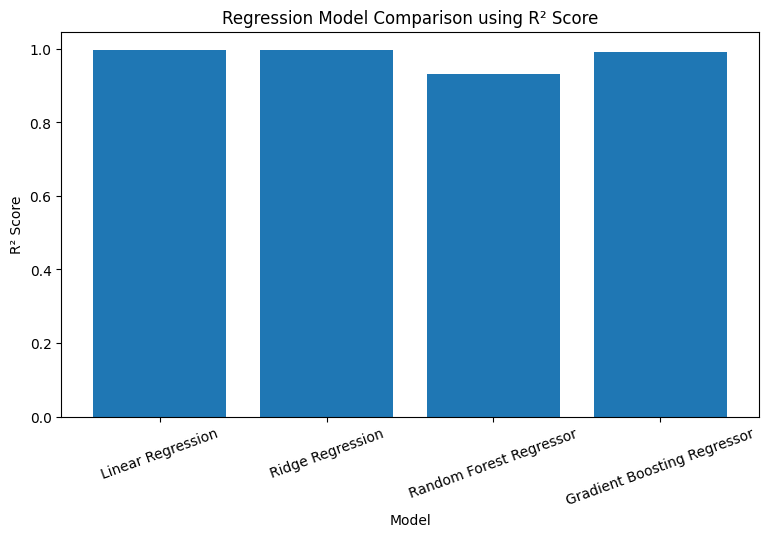

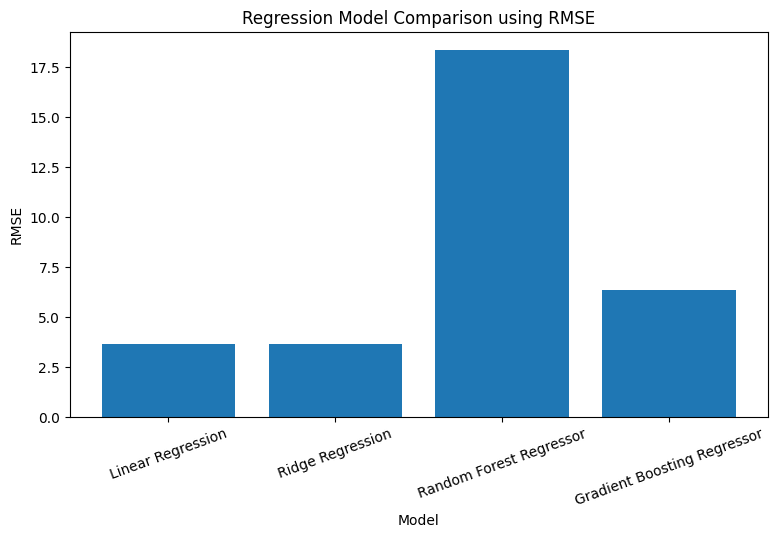

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.304676,3.642935,0.99731


Regression machine learning experiment completed successfully.


In [1]:
# Mount Google Drive so Google Colab can access files stored in Drive
from google.colab import drive
drive.mount('/content/drive')


# Import libraries used for data handling, visualisation, machine learning, and saving models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os


# Import preprocessing and machine learning tools from Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Import regression machine learning models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


# Import regression evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



# Load Dataset
# Path to dataset stored in Google Drive
file_path = "/content/drive/MyDrive/rt_iot2022_regression_ready_50_features.csv"

# Read CSV dataset into a pandas DataFrame
df = pd.read_csv(file_path)

# Display dataset information
print("Dataset Shape:", df.shape)
display(df.head())
df.info()


# Data Cleaning


# Remove duplicate rows to avoid repeated data
df = df.drop_duplicates()

# Replace infinity values with NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Remove rows with missing values
df = df.dropna()

# Display cleaned dataset shape
print("Cleaned Dataset Shape:", df.shape)

# Check remaining missing values
print(df.isnull().sum())


# Define Features and Target Variable


# Target variable for regression
target = "flow_duration"

# X contains all input features except the target
X = df.drop(columns=[target])

# y contains the target values
y = df[target]


# Identify Numerical and Categorical Features

# Select numerical columns
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

# Select categorical columns
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns

# Display feature counts
print("Numerical Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))



# Preprocessing section

# Scale numerical features and encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


# This Splits the Data into Training and Testing Sets

# 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



# This Defines the Regression Models

models = {

    # Simple baseline regression model
    "Linear Regression": LinearRegression(),

    # Ridge Regression helps reduce overfitting
    "Ridge Regression": Ridge(alpha=1.0),

    # Random Forest uses multiple decision trees
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    # Gradient Boosting improves predictions step-by-step
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
}


# Train and Evaluate Models


# Create empty list for storing results
results = []

# Create folder for saving trained models
save_path = "/content/drive/MyDrive/regression_models/"
os.makedirs(save_path, exist_ok=True)

# Loop through each model
for name, model in models.items():

    print("Training:", name)

    # Create machine learning pipeline
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train model using training data
    pipeline.fit(X_train, y_train)

    # Predict target values using testing data
    y_pred = pipeline.predict(X_test)

    # Calculate Mean Absolute Error
    mae = mean_absolute_error(y_test, y_pred)

    # Calculate Root Mean Squared Error
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Calculate R² Score
    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    # Create filename for saved model
    model_filename = (
        save_path +
        name.replace(" ", "_").lower() +
        ".pkl"
    )

    # Save trained model
    joblib.dump(pipeline, model_filename)


# Display Results


# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# Display model performance table
display(results_df)

# Save results as CSV file
results_df.to_csv(
    save_path + "regression_results.csv",
    index=False
)



# Visualise Model Performance

# Plot R² Score comparison
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.title("Regression Model Comparison using R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.show()

# Plot RMSE comparison
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Regression Model Comparison using RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.show()


# Find and Display Best Model


# Sort models by highest R² Score
best_model = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

# Display best-performing model
display(best_model.head(1))

# Print completion message
print("Regression machine learning experiment completed successfully.")


